# Предсказание стоимости домов

Датасет основан на данных из Калифорнии 1990 года и включает метрики популяции, медианного дохода и медианной стоимости домов для каждого блока в Калифорнии. Каждый блок включает от 600 до 3000 людей.

*В конце ответы на вопросы*

` Задача: Предсказывать медианную стоимость домов. `

In [53]:
import kagglehub
import pandas as pd
import seaborn as sb
import numpy as np

# Download latest version
path = kagglehub.dataset_download("kathuman/housing")

print("Path to dataset files:", path)

Path to dataset files: /home/dominator/.cache/kagglehub/datasets/kathuman/housing/versions/1


In [54]:
df = pd.read_csv(path + '/housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


### Сделаем быстрый обзор датасета

In [55]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [56]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Видим, что среднее > медианы, значит, у нас много аномально больших значений.

In [57]:
df.shape

(20640, 10)

In [58]:
df.describe(include='object')

/tmp/ipykernel_4092/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


### Разобъём на тестовую и тренировочную выборку чтобы избежать утечки данных

In [59]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df, test_size=0.3, stratify=df['ocean_proximity'], random_state=42)

Стратификация по ocean_proximity, чтобы сохранить пропорции.

### Проверяем данные и заполняем пропуски

In [60]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

позже заполним пропуски с помощью SimpleImputer

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.median(numeric_only=True)

longitude               -118.4900
latitude                  34.2600
housing_median_age        29.0000
total_rooms             2127.0000
total_bedrooms           435.0000
population              1166.0000
households               409.0000
median_income              3.5348
median_house_value    179700.0000
dtype: float64

Типичная стоимость составляет 179700 долларов.

In [63]:
df.mean(numeric_only=True)

longitude               -119.569704
latitude                  35.631861
housing_median_age        28.639486
total_rooms             2635.763081
total_bedrooms           537.870553
population              1425.476744
households               499.539680
median_income              3.870671
median_house_value    206855.816909
dtype: float64

Дубликатов нет

### Проверим как взаимодействуют признаки

<Axes: >

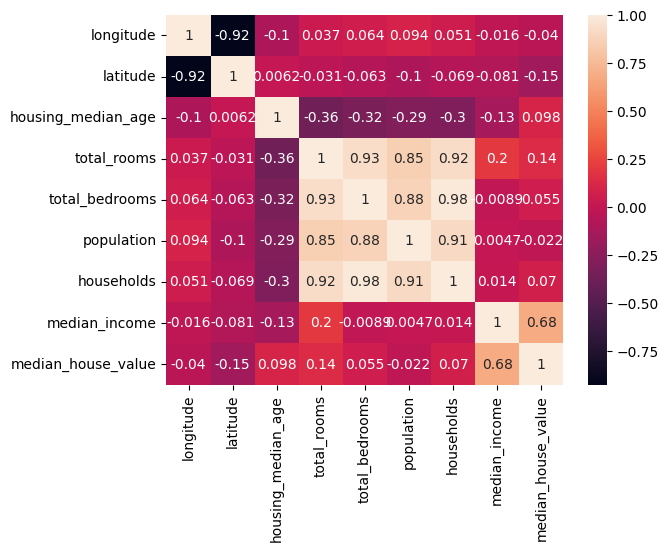

In [64]:
sb.heatmap(train_data.corr(numeric_only=True), annot=True)

Как видим, стоимость сильнее всего зависит от дохода.

### Строим графики

<Axes: xlabel='longitude', ylabel='latitude'>

<Figure size 1500x800 with 0 Axes>

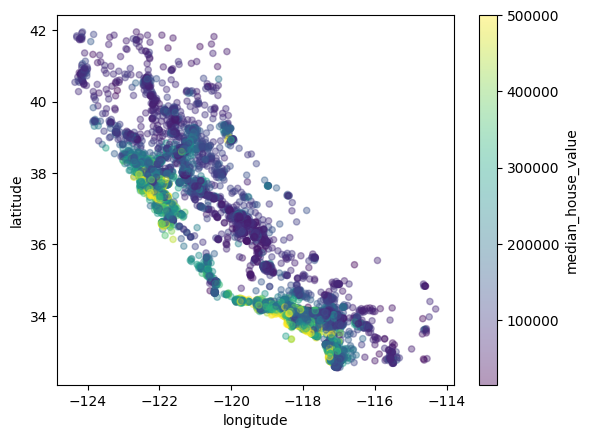

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
train_data.plot(kind='scatter', x="longitude", y='latitude', alpha=0.4, c='median_house_value')

Видим, что на побережье цены выше

Визуализируем фичи.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

<Figure size 2000x1000 with 0 Axes>

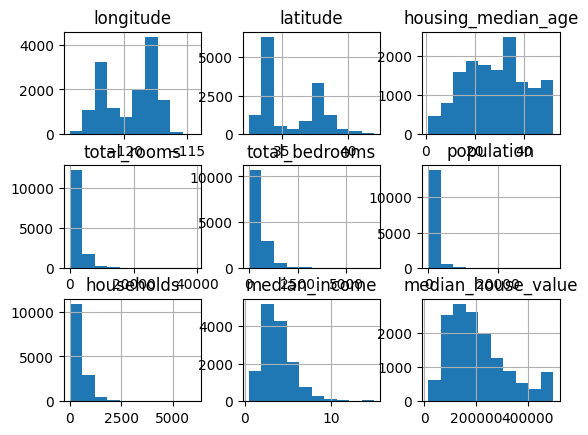

In [66]:
plt.figure(figsize=(20,10))
train_data.hist()

Наблюдаем везде тяжелый хвост справа.

### Препроц

Нормализуем фичи с помощью логарифма и StandardScaler'a. Первый поможет справиться с "тяжелым хвостом", а второй с разбросом единиц измерений. Так же добавим новые признаки: соотношение спальных комнат и подсобок.

In [67]:
def preproc(data):
    data['total_rooms'] = np.log1p(data['total_rooms'])
    data['total_bedrooms'] = np.log1p(data['total_bedrooms'])
    data['population'] = np.log1p(data['population'])
    data['households'] = np.log1p(data['households'])
    data['bedroom_ratio'] = data['total_bedrooms'] / data['total_rooms']
    data['household_rooms'] = data['total_rooms'] / data['households'] 
    
    # уберем эти признаки, чтобы избежать мультиколлинеарности
    data = data.drop('households', axis=1)
    data = data.drop('total_rooms', axis=1)
    data = data.drop('total_bedrooms', axis=1)
    
    return data
    

In [68]:
train_data_preproc = preproc(train_data)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'bedroom_ratio'}>,
        <Axes: title={'center': 'household_rooms'}>, <Axes: >]],
      dtype=object)

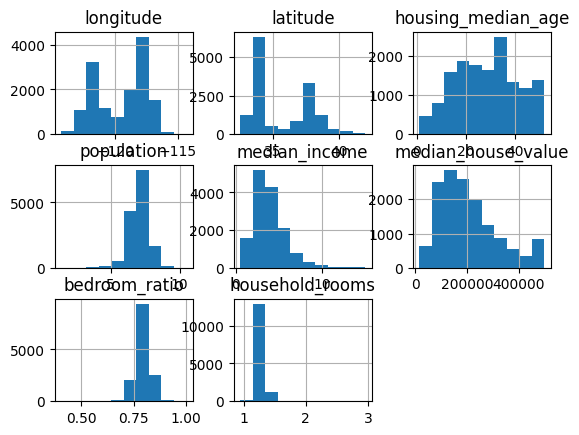

In [69]:
train_data_preproc.hist()

Видим, что структура стала более колоколообразной

In [70]:
test_data_preproc = preproc(test_data)

In [71]:
X_train, y_train = train_data_preproc.drop(['median_house_value'], axis=1),train_data_preproc['median_house_value']
X_test, y_test = test_data_preproc.drop(['median_house_value'], axis=1),test_data_preproc['median_house_value']

Нормализируем данные с помощью StandardScaler тк у нас фичи с разными единицами измерения, что усложняет работу для линейной регрессии, потому что ей сложнее искать гиперплоскости в таких данных.
Так же используем OneHotEncoder чтобы перевести <i>**ocean_promixity**</i> в числовые фичи.

Ещё заполним пустые значения

In [72]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

numeric_cols = ['longitude','latitude','housing_median_age','population','median_income','bedroom_ratio','household_rooms']
categorial_cols = ['ocean_proximity']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[('numeric', num_transformer, numeric_cols),
                     ('categorial', OneHotEncoder(handle_unknown='ignore'), categorial_cols)])

### Тренировка моделей

Делаю пайплайн, чтобы упростить предобработку

In [73]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('linreg', LinearRegression())
])

Тут мы обучаем обычную линейную регрессию, проверяя ее с помощью кросс-валидации с тремя фолдами.

`берем scores.mean() с минусом, т.к. в sklearn философия, чем выше счёт, тем лучше. В случае с rmse это наоборот, чем больше значение, тем больше ошибка, поэтому мы идём в обратную сторону от неё.`

In [82]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring="neg_root_mean_squared_error")
pipeline.fit(X_train, y_train) # кроссвал создает копию, поэтому мы обучаем модель самостоятельно еще раз
-scores.mean(), scores.std()

(np.float64(69917.36581535882), np.float64(523.326828150647))

Видим, что у нас среднее отклонение равно $69378. Проверим, чего можно достичь с l1 и l2 регуляризациями.

Обучим модель с l2-регуляризацией (подберем наилучший параметр alpha с помощью gridsearch)

In [75]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge(random_state=42))
])

param_grid = {
    "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

gscv = GridSearchCV(pipeline_ridge, cv=3, param_grid=param_grid)
gscv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candid

In [ ]:
best_ridge = gscv.best_estimator_
best_ridge.fit(X_train, y_train).score(X_test, y_test) 
scores = cross_val_score(best_ridge, X_train, y_train, cv=3, scoring="neg_root_mean_squared_error")
-scores.mean(), scores.std()

(np.float64(69917.0570954897), np.float64(514.2322424989367))

Как видим, Ridge имеет почти такую же ошибку, однако ведет себя стабильнее, чем обычная лин. регрессия, тк стандартное отклонение у нее теперь составляет 514 (0.73%)

Теперь попробуем Lasso (l1-регуляризацию)

In [77]:
from sklearn.linear_model import Lasso
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', Lasso(random_state=42))
])

param_grid = {
    "lasso__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

gscv = GridSearchCV(pipeline_lasso, cv=3, param_grid=param_grid)
gscv.fit(X_train, y_train)

/home/dominator/miniconda3/envs/mlcourse/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.848e+12, tolerance: 1.292e+10
  model = cd_fast.enet_coordinate_descent(
/home/dominator/miniconda3/envs/mlcourse/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.854e+12, tolerance: 1.290e+10
  model = cd_fast.enet_coordinate_descent(
/home/dominator/miniconda3/envs/mlcourse/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candid

In [78]:
best_lasso = gscv.best_estimator_
best_lasso.fit(X_train, y_train).score(X_test, y_test) 
scores = cross_val_score(best_lasso, X_train, y_train, cv=3, scoring="neg_root_mean_squared_error")
-scores.mean(), scores.std()

(np.float64(69911.4911058556), np.float64(497.01656342580577))

Лассо показало себя еще чуть лучше, чем Ridge.

### Теперь сравним модели в удобном виде

In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def compare_models_metrics(models_dict, X_test, y_test):
    results = []
    
    for name, model in models_dict.items():
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results.append({
            'Model': name,
            'RMSE': round(rmse, 2),
            'MAE': round(mae, 2),
            'R^2': round(r2, 4)
        })
    
    # для красивого форматирования
    return pd.DataFrame(results).sort_values(by='RMSE')


In [84]:
models = {
    'Linear Regression': pipeline,
    'Ridge Regression': best_ridge, 
    'Lasso Regression': best_lasso
}

comparison_table = compare_models_metrics(models, X_test, y_test)
display(comparison_table)

,Model,RMSE,MAE,R^2
0,Linear Regression,69392.04,50111.17,0.6381
1,Ridge Regression,69399.03,50109.55,0.6381
2,Lasso Regression,69415.61,50109.81,0.6379


Как видим, rmse почти не отличаются благодаря качественной обработке данных. Везде эта метрика составляет примерно 70000 долларов, что довольно много по отношению к средней цене домов (34%) :((

### Ответы на вопросы

* Как вы предобрабатывали данные?
    - заполнил пропуски медианой с помощью SimpleImputer
    - избавился от схожих фич, скомбинировав их
    - взял логарифм для уменьшения "длинного хвоста"
    - привел к общим единицам измерения с помощью StandardScaler
    - перевел категориальный признак "ocean_proximity" в числовой с помощью OneHotEncoder

* Что вы поняли, проведя EDA?
    - дома дороже на побережье
    - стоимость домов главным образом зависит от медианы дохода
    - у нас много аномально больших значений

* Как вы работали с признаками?
    - см. "Как вы предобрабатывали данные?"
* Какие признаки вы добавили / изменили и почему?
    - добавил признаки "bedroom_ratio" и "household_rooms" чтобы дать смысл уже имеющимся признакам и избежать мультиколлинеарности
* Какие признаки вы удалили и почему?
    - это признаки total_bedrooms, total_rooms, households тк они бы приводили к мультиколлинеарности.

* Как именно вы разделили выборку?
    - с помощью train_test_split, тестовый сет составляет 30% от общего, при этом стратифицируем по ocean_proximity, чтобы выборка сохраняла реальные пропорции.

* Для чего это нужно? 
    - если бы мы не разделяли данные, то после прохода различными трансформерами модель бы уже "знала", какие отклонения имеет выборка, поэтому ее невозможно было бы объективно оценить на этих данных. Это и есть утечка.

* Как проходило обучение моделей?
    - Я поискал параметры alpha для Ridge и Lasso, и если ridge не сильно поменялся, то Lasso с дефолтным значением давал стандартное отклонение 523, то с alpha = 100 его отклонение составляет 497.

* Сравнение скорости:
    - в режиме экономии энергии на моём ноутбуке (intel core i7-8550U, 16 gb ram) (не на gpu) gridsearch по Ridge отрабатывает в 3 раза быстрее, чем по Lasso. Lasso использует итерационное решение, а Ridge аналитическое, поэтому, первое работает дольше.

* Какие метрики вы использовали для сравнения моделей?
    - rmse, mae и R^2. RMSE сильнее штрафует за ошибки, что важно при оценке недвижимости, так что ориентируемся на неё.
* На какой части выборки вы считали метрики?
    - на тестовой, так как её результат и показывает, насколько точна модель в реальных условиях
* Какая модель по итогу справилась лучше?
    - по каждой метрике есть свой лидер, но если брать rmse за эталон, то на этих данных лучше всего LinearRegression
* Насколько хорошие получились результаты?
    - с погрешностью в 30% мы не сможем точно предсказывать стоимости в реальном мире, возможно, тут стоит использовать нелинейную модель
* Чем докажете, что ваша модель не переобучилась?
    - сверим:


In [85]:
train_res = compare_models_metrics({'Linear Regression': pipeline}, X_train, y_train)
test_res = compare_models_metrics({'Linear Regression': pipeline}, X_test, y_test)

display(train_res)
display(test_res)

,Model,RMSE,MAE,R^2
0,Linear Regression,69751.08,50498.92,0.6347


,Model,RMSE,MAE,R^2
0,Linear Regression,69392.04,50111.17,0.6381


Как видим, у нас нет такого, что на тренировочных данных модель сильно лучше, чем на тестовых. Это доказывает, что модель не переобучилась.